In [1]:
from rdkit import Chem

smiles = "CCO"

mol = Chem.MolFromSmiles(
    smiles
)

print(
    "Atoms:",
    mol.GetNumAtoms()
)

print(
    "Bonds:",
    mol.GetNumBonds()
)

Atoms: 3
Bonds: 2


inspect atoms

In [2]:
for atom in mol.GetAtoms():

    print(
        atom.GetIdx(),
        atom.GetSymbol()
    )

0 C
1 C
2 O


inspect bonds

In [3]:
for bond in mol.GetBonds():

    print(
        bond.GetBeginAtomIdx(),
        bond.GetEndAtomIdx()
    )

0 1
1 2


convert to networkX

In [4]:
import networkx as nx
from rdkit import Chem

mol = Chem.MolFromSmiles(
    "CCO"
)

G = nx.Graph()

for atom in mol.GetAtoms():

    G.add_node(
        atom.GetIdx(),
        symbol=atom.GetSymbol()
    )

for bond in mol.GetBonds():

    G.add_edge(
        bond.GetBeginAtomIdx(),
        bond.GetEndAtomIdx()
    )

print(
    G.nodes(data=True)
)

print(
    G.edges()
)

[(0, {'symbol': 'C'}), (1, {'symbol': 'C'}), (2, {'symbol': 'O'})]
[(0, 1), (1, 2)]


visualize molecule graph

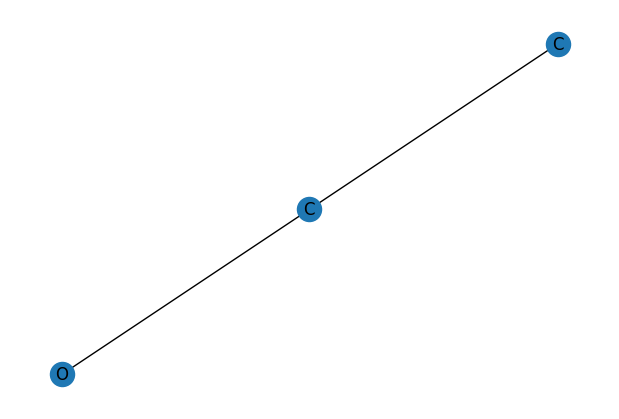

In [5]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(
    G,
    seed=42
)

labels = {
    n: d["symbol"]
    for n, d in G.nodes(data=True)
}

plt.figure(
    figsize=(6,4)
)

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True
)

plt.show()